# EDA(데이터 탐색)

EDA의 유형은 **대상**이 일변량인지 다변량인지, **종류**가 시각화인지 비시각화인지에 따라 4가지로 나뉨.

## 1. 데이터 확인 (파일 불러오는 과정)

### 절대 경로로 불러오기

```python
pd.read_csv('/Users/ldbzoey/__Insight/2025_1st/교육팀/EDA실습준비/titanic.csv')
```

### 상대 경로로 불러오기

현재 작업 중인 디렉터리를 기준으로 상대적으로 표현하는 방식.

- `./` : 현재 디렉터리
- `../` : 상위 디렉터리
- `/` : 최상위(루트) 디렉터리

```python
pd.read_csv('./titanic.csv')
```

주로 **CSV**(주로 메모장)랑 **EXCEL** 파일을 이용함.

**IF EXCEL에 여러 시트로 구성되어 있다면?**
- 특정 시트 불러오기: `pd.read_excel('파일경로/파일이름.xlsx', sheet_name='불러올 시트')`
- 여러 시트 불러오기: `pd.read_excel('파일경로/파일이름.xlsx', sheet_name=['시트1', '시트2'])`

---

## 2. 데이터셋 파악

`head(n)` → 데이터 상위 n개 보여줌

컬럼이 특징이자 변수인데, 유형과 형식을 확인해야 함.

**범주형(Categorical)** : 몇 개의 범주로 나누어진 데이터
**수치형(Numerical)** : 숫자로 표현되는 데이터

- **명목형(Nominal)** : 성별, 성공여부, 혈액형 등 순서와 상관없이 이름만 의미를 부여할 수 있는 경우. 카테고리 간에 크고 작음이나 순서 개념이 없고, 단순히 "다르다/같다"만 구분하는 데이터.
- **순서형(Ordinal)** : 범주형 데이터 중 어떤 기준에 따라 순서에 의미를 부여할 수 있는 경우. 예를 들어 학년(1학년<2학년<3학년)처럼 순서는 있지만, 그 간격이 일정하다고 보긴 어려운 데이터.
- **이산형(Discrete)** : 이산적인 값으로, 정수 단위로 떨어져 셀 수 있는 데이터. 값과 값 사이를 더 쪼갤 수 없고 "몇 개"로 셀 수 있는 게 특징 (형제 수, 자녀 수 등).
- **연속형(Continuous)** : 연속적인 값을 갖는 데이터로 신장, 체중 등. 두 값 사이에 이론상 무한히 더 세밀한 값이 존재할 수 있는 데이터.

>  정수냐 소수냐가 기준이 아니라, 구간을 잘랐을 때 개수로 셀 수 있는지 여부가 이산형/연속형을 가르는 기준!

**중요!!** 마지막으로 데이터 분포(평균, 최빈, 중앙) 확인해야 함.

- **산포도(Scatter Plot)** : 두 변수 간의 관계를 점으로 찍어서 보여주는 그래프. 점들이 흩어진 모양을 보고 두 변수가 어떤 방향으로 같이 움직이는지 파악할 수 있음.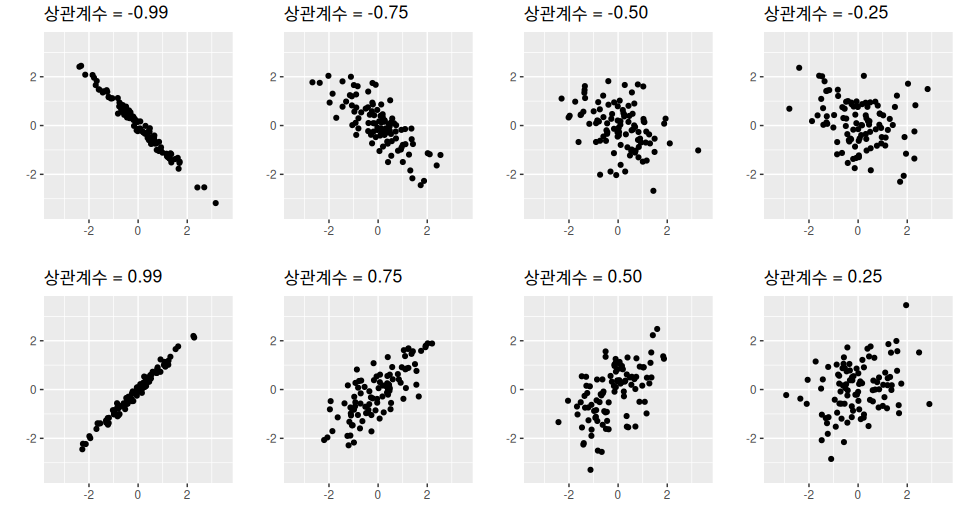
- **박스플롯(Box Plot)** : 데이터의 중앙값, 사분위수, 이상치를 한눈에 보여주는 그래프. 상자의 크기와 위치로 데이터가 얼마나 퍼져있는지, 어디에 몰려있는지 파악할 수 있음.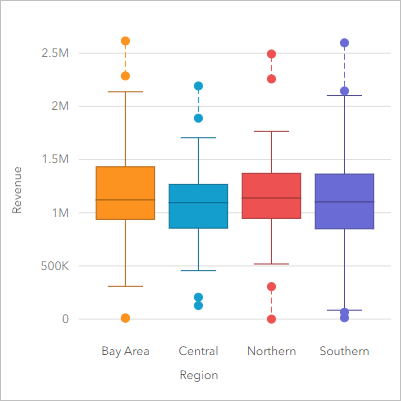
- **히스토그램(Histogram)** : x축이 범위,분포로 되어있는 막대그래프

# 데이터 전처리
? 데이터를 분석에 적합한 형태로 만드는 과정

전처리 기술 4가지: 정제(결측값 보완/이상값 제거) / 변환(일관성 확보) / 필터링(오류 발견 및 보정) / 통합(유사 데이터 연계)

## 결측값 처리
? 데이터 수집 과정에서 측정되지 않거나 누락된 데이터 (NaN, ?, 0 등으로 표시됨)
- 0인 경우 진짜 0인지 결측이라 0으로 표기된건지 확인 필요

**확인**
- info() : 열별 non-null 개수 확인
- isnull().sum() : 결측값 개수 (자주 씀!)
- value_counts(dropna=False) : 결측 포함 전체 확인
- replace() : NaN 아닌 '0','?' 등으로 표시된 결측값을 NaN으로 변환

**처리 방법**
1) 삭제 - dropna(axis, how, subset, inplace)
   - axis=0(행)/1(열), how='any'(하나라도)/'all'(전부), subset=['컬럼명']
   - 결측이 무작위로 발생했을 때만 사용! 아니면 모델 왜곡됨
```
df.dropna(subset=['A', 'B'])
```

2) 대체 - fillna()
   - 일괄 대체: 전체 평균값 등으로 통일
   - 유사 유형 대체: 범주별로 그룹화 후 그룹 평균으로 대체
   - 이웃값 대체: ffill()(직전값) / bfill()(다음값)
```
a = df["열1"].mean(axis=0)
df["열1"].fillna(a, inplace=True)

df['Value'] = df.groupby('Category')['Value'].apply(lambda x: x.fillna(x.mean()))
```

---

## 이상값 처리
? 관측된 데이터 범위에서 많이 벗어난 값

**확인 방법**
- 통계: describe()
- 시각화: BoxPlot
- Z-score: 평균(0)·표준편차(1)로 정규화 → 평균에서 얼마나 떨어졌는지, 보통 2~3 넘으면 이상치
- Tukey Fences: IQR(사분위범위) 기반, Q1-1.5×IQR 미만 or Q3+1.5×IQR 초과면 이상치 (배율은 데이터 특성따라 조절 가능)
```
def find_outlier_by_Tukey_DF(data, feature):
    q1, q3 = np.percentile(data[feature],[25,75])
    iqr = q3-q1
    lower_bound = q1 - (iqr * 1.5)
    upper_bound = q3 + (iqr * 1.5)
    mask = data[(data[feature] > upper_bound) | (data[feature] < lower_bound)].index
    return mask
```

**처리 방법**
1) 전체 삭제 - Human error(오타, 비현실적 응답 등)로 발생한 경우
2) 다른 값 대체 - 관측치 수가 적어서 삭제하면 신뢰성 떨어질 때, 평균 등으로 대체하거나 예측모델로 대체
3) 변수화 - 자연발생 이상치일 때, 삭제 대신 특성을 Yes/No 등으로 변수화해서 모델에 포함 (ex. 연봉 특이값 → 전문직 여부 변수 추가)
4) 리샘플링 - 독립변수·종속변수 둘 다에서 이상치인 경우, 이상값 포함/제외 모델 둘 다 만들어서 비교

> 자연발생 이상치는 바로 삭제하지 말고 원인부터 파악하는 게 중요

---

## 변수 가공 
? 피처(변수)들의 형태를 변형/처리해서 컴퓨터가 잘 이해하게 만드는 과정 (전처리 마지막 단계)

**4가지 방식**

1) 레이블/원핫 인코딩 - 문자열 → 숫자 변환
   - Label Encoding: 범주를 0~N-1 숫자로
   - One-Hot Encoding: 이진 벡터(0,1)로, 해당 인덱스만 1
```
data_dummies = pd.get_dummies(data['Survived'], drop_first=True, dtype=int)
```

2) 구간화(Binning) - 연속값을 일정 구간으로 나눠서 이산화 (ex. 신용카드 이용액 → 프리미엄 등급)
```
count, bin_dividers = np.histogram(df["카테고리"], bins=3)
bin_names = ["상", "중", "하"]
df["new_bins"] = pd.cut(x=df["카테고리"], bins=bin_dividers, labels=bin_names, include_lowest=True)
```

3) 파생변수 생성 - 기존 피처를 변환해 새 피처 추가 (단위변환, 표현형식변환, 정보추출, 변수결합 등) ex. 검수일자 → 검수요일

4) 스케일링 - 변수 값 범위를 일정 수준으로 맞추는 작업, 이상치 제거 선행 필요
   - StandardScaler: 평균 0, 분산 1로 표준화 → 정규분포 가정 기술에 적합
   - MinMaxScaler: 0~1 사이로 정규화 → 속성 비율 다를 때, 연산속도/최적화에 효과적
```
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()
df['스케일링컬럼'] = scaler.fit_transform(df[['기존컬럼']])

scaler = MinMaxScaler()
df['스케일링컬럼'] = scaler.fit_transform(df[['기존컬럼']])
```

# 데이터 시각화
? 데이터에 대한 이해를 돕기 위해 그림, 도형 등 그래픽 요소로 데이터를 묘사하고 표현하는 과정

시각화로 숫자·텍스트를 그래프/차트/도표로 바꿔서 패턴, 관계, 추세를 쉽게 파악 가능

**주로 쓰는 라이브러리**
- Matplotlib: Python + NumPy 기반 플로팅 라이브러리
- Seaborn: matplotlib 기반, 통계 데이터 시각화에 최적화

시각화 전에 데이터가 범주형/수치형인지, 결측값·이상치 있는지부터 확인 후 그래프 종류 선택

## 파라미터
파라미터(매개변수) = 함수의 입력값 자리, 인자(argument) = 실제 전달되는 값

ex. countplot(data=data, x='Survived')
- data, x → 파라미터
- data(데이터프레임), 'Survived' → 인자

```
def 함수이름(파라미터1, 파라미터2):
    print(파라미터1, 파라미터2)

함수이름("인자1", "인자2")
```

**hue 파라미터**: 성별 같은 범주형 변수를 넣어서 그 기준으로 데이터를 구분해 그래프에 표시

**테마/색상 바꾸기**
```
sns.set_theme(context='notebook', style='darkgrid', palette='deep', font='Malgun Gothic', font_scale=1, rc=custom_params)
```

---

## 그래프 종류

**1) boxplot** - 사분위수와 이상치를 보여줌
```
sns.boxplot(x="day", y="total_bill", data=tips, showfliers=False)
```
- showfliers=False로 이상치 표시 끄기 가능

**2) countplot, histplot**
- countplot: 범주형 변수의 빈도수 확인
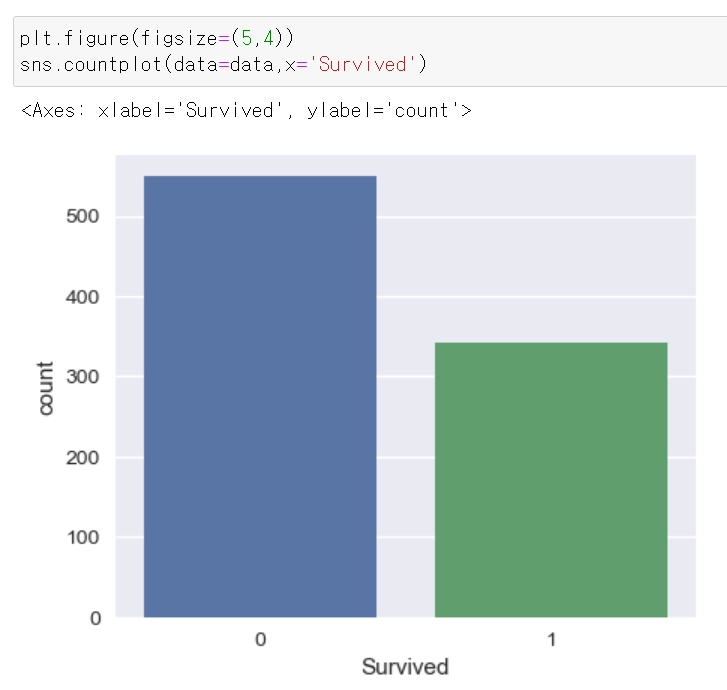
- histplot: 수치형 변수의 구간별 빈도수 (도수분포표)
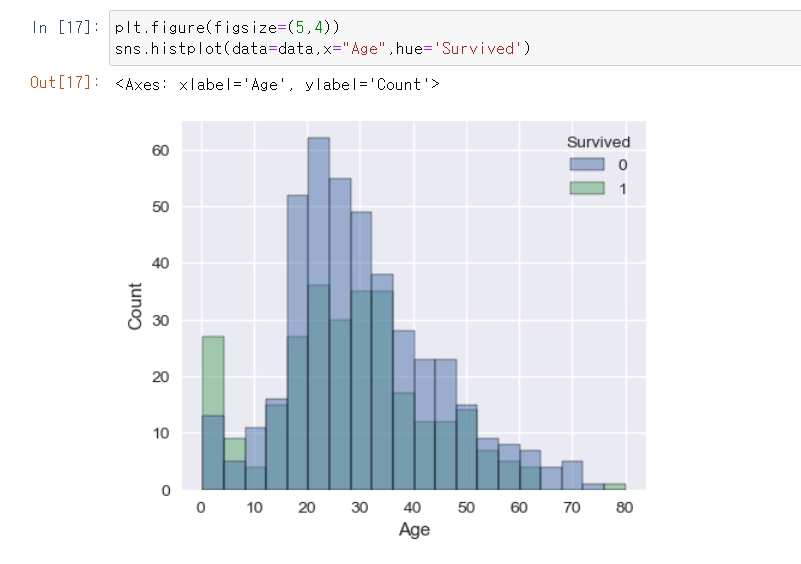
**3) displot, kdeplot** - 히스토그램을 곡선으로 연결한 커널밀도추정 그래프 (kde=True로 곡선 표현)
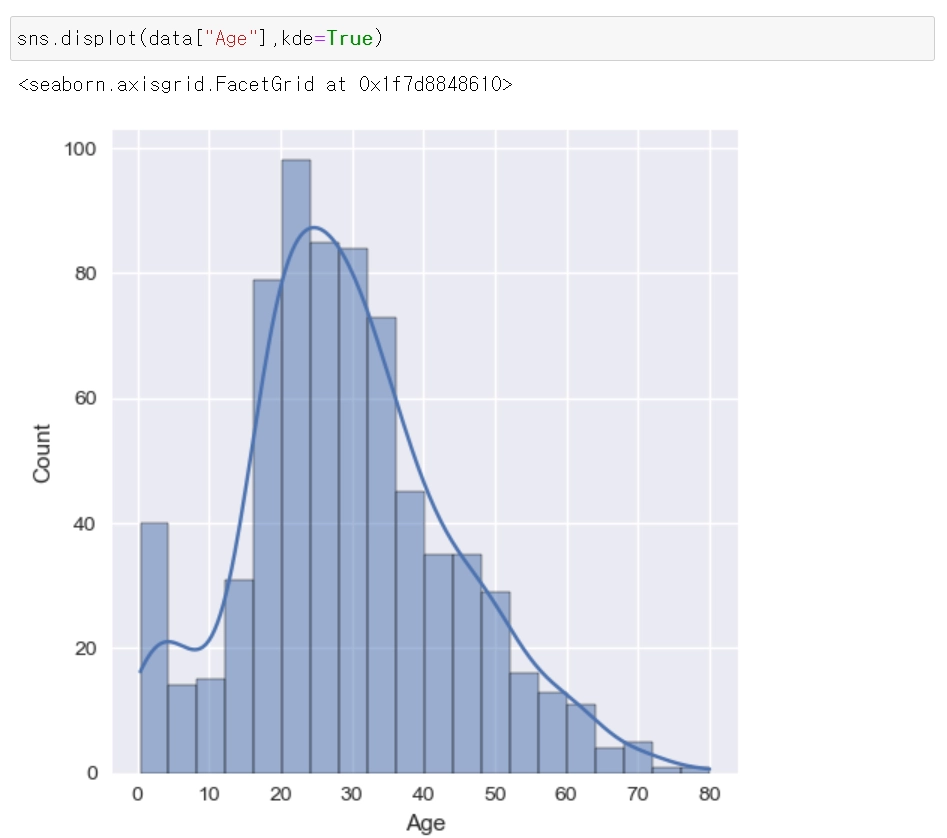
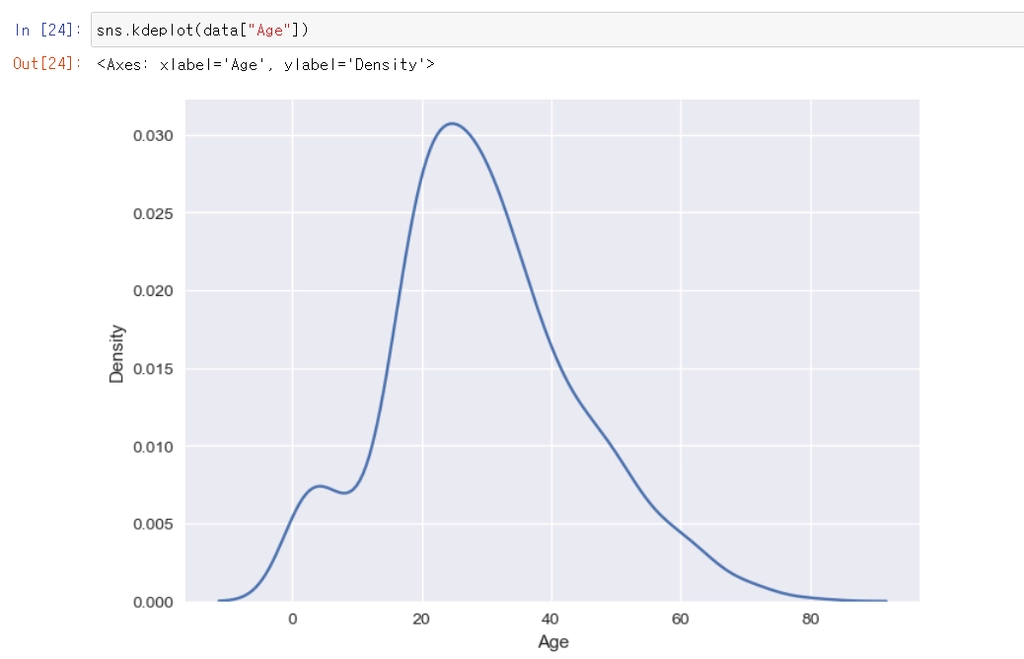

**4) barplot, pointplot**
- barplot: 범주형 x에 따른 수치형 y의 평균값, 검은선은 신뢰구간(CI)
- pointplot: barplot과 모양만 다르고 동일 정보 제공
- 기본 95% 신뢰구간, 선이 짧으면 변동 적음/길면 변동 큼
```
sns.barplot(data=data, x="Sex", y="Age", hue="Survived", ci=None)  # CI 제거
sns.barplot(data=data, x="Sex", y="Age", hue="Survived", ci=68)    # CI 68%로 지정
```

**5) scatterplot, regplot**
- scatterplot: 두 연속형 변수 간 관계, 패턴·상관관계·분포 파악
- regplot: scatterplot + 회귀선 (fit_reg=False로 회귀선 숨김)

**6) catplot** - 수치형+범주형 데이터의 관계 확인용
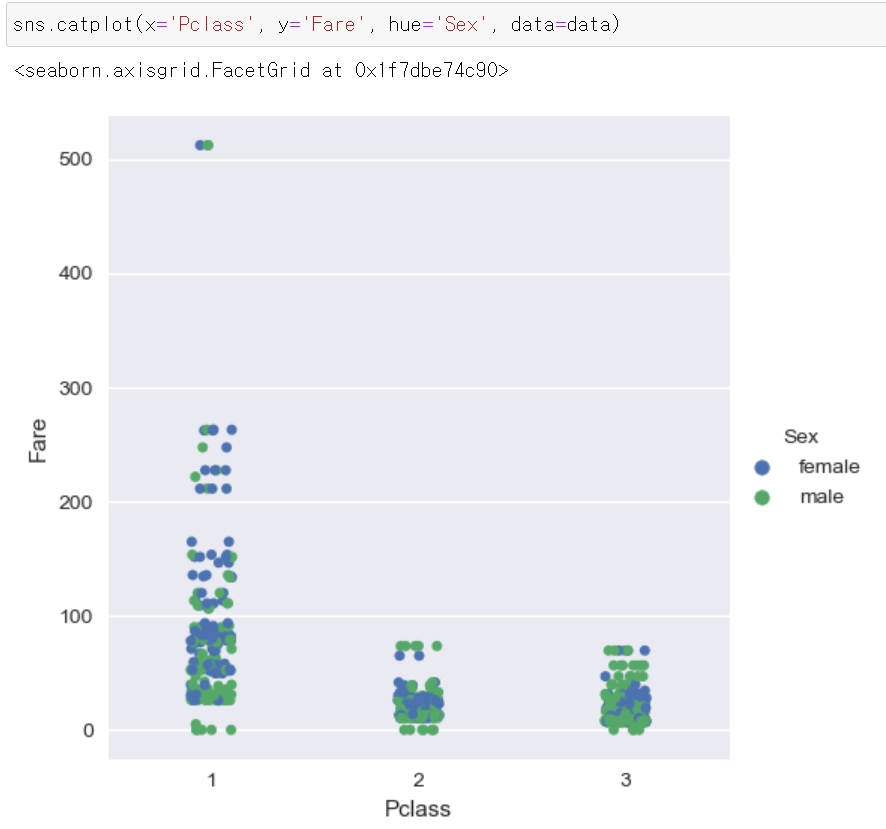

**7) pieplot**(파이차트?) - 부분과 전체의 비율 표현, 전체 합이 100%일 때 효과적
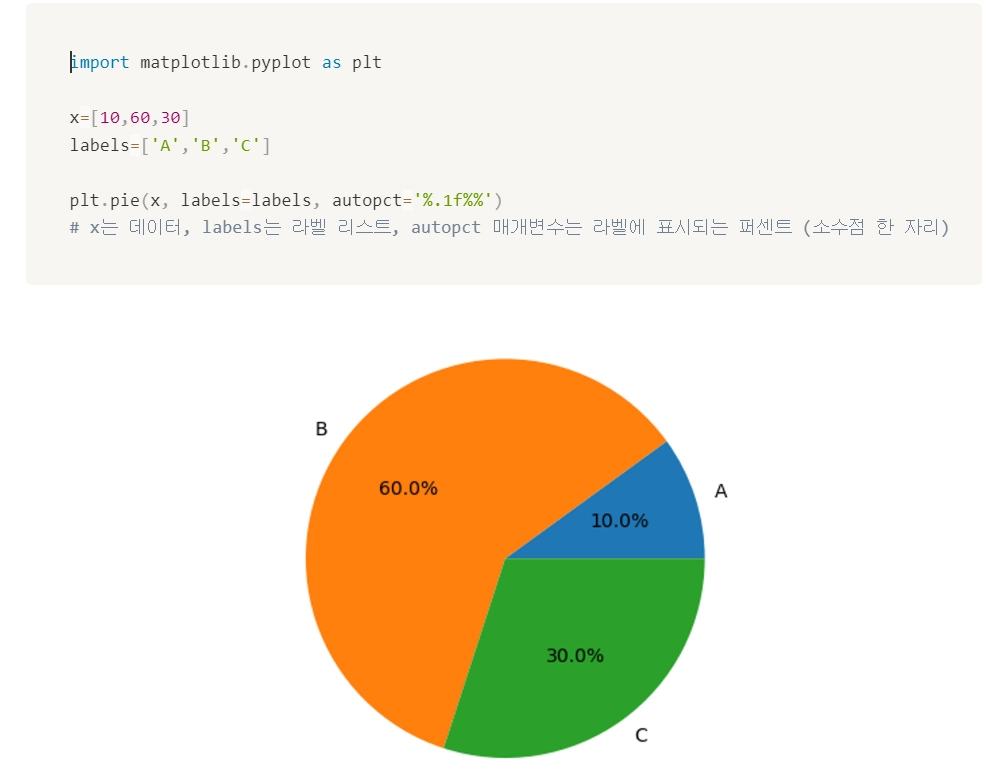

**8) heatmap** - 변수 간 상관계수 시각화 
```
sns.heatmap(df.corr(), annot=True)  # annot: 상관계수 값 표시 여부
```
- 상관계수: -1~1 사이, 절댓값 클수록 상관 강함
  - 음수: 반비례 / 양수: 비례
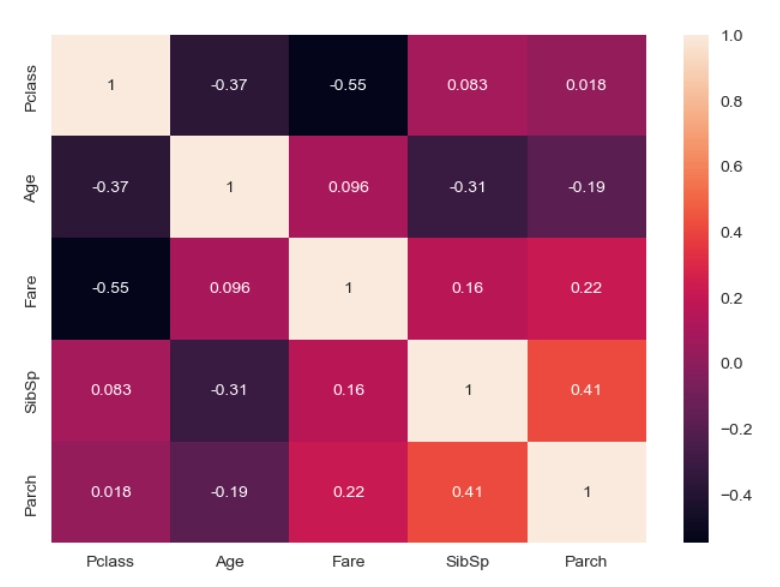

**9) violinplot** - boxplot + 커널밀도추정을 합친 그래프, 분포를 더 정밀하게 보여줌
```
sns.violinplot(x='class', y='age', data=data)
sns.violinplot(x='class', y='age', hue='sex', data=data, split=True)  # 성별 나눠서 비교
```
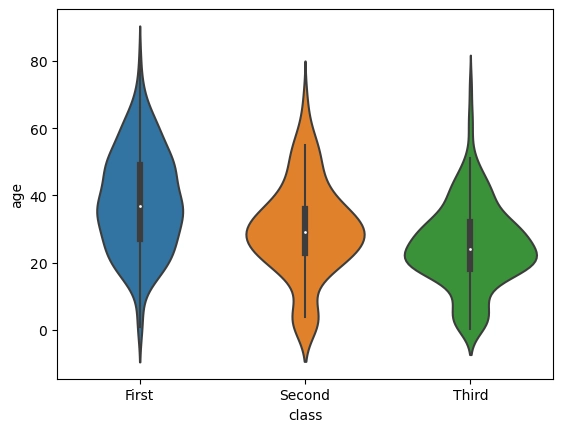

**10) pairplot** - 여러 변수 간 산점도를 한번에 다 보여주는 그래프 (여러 그래프를 ax[i]로 원하는 위치에 배치 가능)